In [13]:
from pathlib import Path
import random
from PIL import Image
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
test_data_folder = Path("../src/Dataset/test_data")

In [4]:
def load_data(folder) -> list:
    data_rgb = []

    for file in folder.glob("*.png"):
        image = Image.open(file).convert("RGB")
        data_rgb.append(image.copy())
        image.close()

    print("Count of loaded .png images:", len(data_rgb))
    return data_rgb

loaded_data_rgb = load_data(test_data_folder)

Count of loaded .png images: 71


In [8]:

class JPEGCodecTransform:
    def __init__(self, block_size: int = 8, color_space: str = "YCbCr"):
        """Initialize the JPEG codec transform."""
        self.N = block_size
        self.color_space = color_space
        self.C = self._dct_matrix(block_size) # Precompute the DCT matrix for the given block size

    def _dct_matrix(self, N: int) -> np.ndarray:
        """ Compute the DCT transformation matrix for a given block size N. """
        C = np.zeros((N, N), dtype=np.float64)
        for i in range(N):
            for j in range(N):
                alpha = np.sqrt(1 / N) if i == 0 else np.sqrt(2 / N)
                C[i, j] = alpha * np.cos(((2 * j + 1) * i * np.pi) / (2 * N))
        return C
    
    def _split_blocks(self, channel):
        """Split a single color channel into non-overlapping blocks."""
        H, W = channel.shape
        assert H % self.N == 0 and W % self.N == 0, "Image dimensions must be divisible by block size"
        return channel.reshape(
            H // self.N, self.N,
            W // self.N, self.N
        ).transpose(0, 2, 1, 3)

    def _merge_blocks(self, blocks):
        """Merge blocks back into a single color channel."""
        nb_h, nb_w, bh, bw = blocks.shape
        return blocks.transpose(0, 2, 1, 3).reshape(nb_h * bh, nb_w * bw)
    
    def _dct2(self, block):
        """Apply 2D DCT to an 8x8 block."""
        return self.C @ block @ self.C.T
    
    def _idct2(self, block):
        """Apply 2D inverse DCT to an 8x8 block."""
        return self.C.T @ block @ self.C
    
    def transform_blocks(self, blocks):
        """Apply DCT to each block."""
        out = np.empty_like(blocks, dtype=np.float64)
        for i in range(blocks.shape[0]):
            for j in range(blocks.shape[1]):
                out[i, j] = self._dct2(blocks[i, j])
        return out
    
    def inverse_transform_blocks(self, blocks):
        """Apply inverse DCT to each block."""
        out = np.empty_like(blocks, dtype=np.float64)
        for i in range(blocks.shape[0]):
            for j in range(blocks.shape[1]):
                out[i, j] = self._idct2(blocks[i, j])
        return out
    
    
    def transform(self, image: Image.Image) -> dict:
        """Transform the input image using DCT and return a dictionary with the transformed data."""
        arr = np.asarray(image.convert(self.color_space), dtype=np.uint8).astype(np.float64) - 128.0
        channels = []

        for c in range(3):
            blocks = self._split_blocks(arr[:, :, c])
            dct_blocks = self.transform_blocks(blocks)
            channels.append(dct_blocks)

        return {
            "ch1": channels[0],
            "ch2": channels[1],
            "ch3": channels[2]
        }

    def inverse_transform(self, encoded: dict) -> Image.Image:
        """Inverse transform the encoded data back to an image."""
        rec_channels = []

        for key in ["ch1", "ch2", "ch3"]:
            blocks = self.inverse_transform_blocks(encoded[key])
            rec_channels.append(self._merge_blocks(blocks))
        
        rec = np.stack(rec_channels, axis=-1)
        rec = np.clip(rec + 128.0, 0, 255).astype(np.uint8)
        if self.color_space == "YCbCr":
            return Image.fromarray(rec, mode="YCbCr").convert("RGB")
        else:
            return Image.fromarray(rec)


In [33]:
codec = JPEGCodecTransform(block_size=8, color_space="YCbCr")

img = loaded_data_rgb[32]

transformed = codec.transform(img)
reconstructed = codec.inverse_transform(transformed)

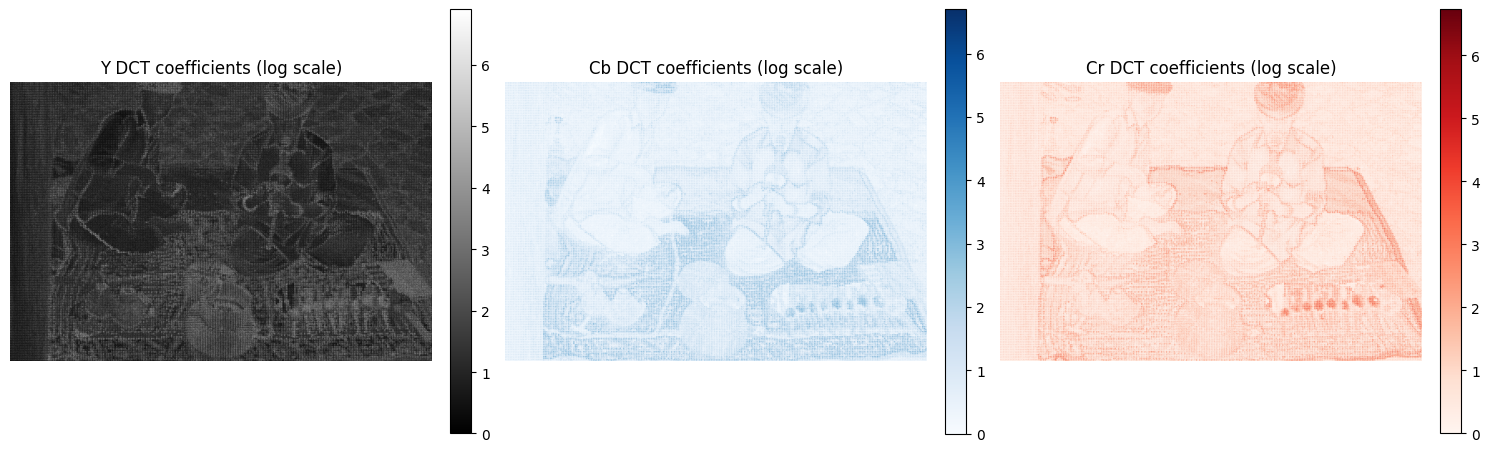

In [34]:
def plot_transformed_image(encoded, codec, channel_names=("Y", "Cb", "Cr"), log_scale=True):
    """
    Plot the transformed DCT coefficient image for each channel.

    Parameters
    ----------
    encoded : dict
        Output from codec.transform(image), with keys "ch1", "ch2", "ch3".
    codec : JPEGCodecTransform
        Your codec object. Used for _merge_blocks().
    channel_names : tuple
        Names to show for each channel. For YCbCr, use ("Y", "Cb", "Cr").
    log_scale : bool
        If True, plots log(1 + abs(DCT coefficients)).
        If False, plots raw DCT coefficients.
    """
    keys = ["ch1", "ch2", "ch3"]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for ax, key, name in zip(axes, keys, channel_names):
        coeff_image = codec._merge_blocks(encoded[key])

        if log_scale:
            display_image = np.log1p(np.abs(coeff_image))
            title = f"{name} DCT coefficients (log scale)"
        else:
            display_image = coeff_image
            title = f"{name} DCT coefficients"

        if name == "Y":
            cmap = "gray"
        elif name == "Cb":
            cmap = "Blues"
        else:
            cmap = "Reds"
        im = ax.imshow(display_image, cmap=cmap)
        ax.set_title(title)
        ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()
plot_transformed_image(transformed, codec)

In [20]:
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt


def mse(original, reconstructed):
    """Calculate Mean Squared Error between two images."""
    original = np.asarray(original.convert("RGB"), dtype=np.float64)
    reconstructed = np.asarray(reconstructed.convert("RGB"), dtype=np.float64)
    return np.mean((original - reconstructed) ** 2)


def psnr(original, reconstructed, max_val=255.0):
    """Calculate Peak Signal-to-Noise Ratio between two images."""
    err = mse(original, reconstructed)
    if err == 0:
        return np.inf
    return 10 * np.log10((max_val ** 2) / err)


def max_abs_error(original, reconstructed):
    """Calculate Maximum Absolute Error between two images."""
    original = np.asarray(original.convert("RGB"), dtype=np.float64)
    reconstructed = np.asarray(reconstructed.convert("RGB"), dtype=np.float64)
    return np.max(np.abs(original - reconstructed))


def changed_pixel_percentage(original, reconstructed):
    """ Calculate the percentage of pixels that have changed in any channel between the original and reconstructed images."""
    original = np.asarray(original.convert("RGB"), dtype=np.uint8)
    reconstructed = np.asarray(reconstructed.convert("RGB"), dtype=np.uint8)

    changed = np.any(original != reconstructed, axis=-1)
    return 100 * np.mean(changed)


def pad_to_block_size(image, block_size=8):
    """
    Pads image dimensions so they are divisible by block_size.
    Uses edge padding, which is more natural than zero padding for images.
    """
    arr = np.asarray(image.convert("RGB"))
    H, W, C = arr.shape

    pad_h = (block_size - H % block_size) % block_size
    pad_w = (block_size - W % block_size) % block_size

    padded = np.pad(
        arr,
        ((0, pad_h), (0, pad_w), (0, 0)),
        mode="edge"
    )

    return Image.fromarray(padded), H, W


def crop_to_original_size(image, H, W):
    arr = np.asarray(image)
    return Image.fromarray(arr[:H, :W])


def evaluate_transform_only(image_paths, codec):
    rows = []

    # Accumulates mean absolute DCT coefficients over all images and all blocks.
    coeff_abs_sum = {
        "Y": np.zeros((codec.N, codec.N), dtype=np.float64),
        "Cb": np.zeros((codec.N, codec.N), dtype=np.float64),
        "Cr": np.zeros((codec.N, codec.N), dtype=np.float64),
    }

    block_counts = {
        "Y": 0,
        "Cb": 0,
        "Cr": 0,
    }

    for path in image_paths:
        image = Image.open(path).convert("RGB")

        padded_image, H, W = pad_to_block_size(image, codec.N)

        encoded = codec.transform(padded_image)
        reconstructed_padded = codec.inverse_transform(encoded)
        reconstructed = crop_to_original_size(reconstructed_padded, H, W)

        rows.append({
            "image": Path(path).name,
            "mse": mse(image, reconstructed),
            "psnr": psnr(image, reconstructed),
            "max_abs_error": max_abs_error(image, reconstructed),
            "changed_pixel_percentage": changed_pixel_percentage(image, reconstructed),
        })

        for key, channel_name in zip(["ch1", "ch2", "ch3"], ["Y", "Cb", "Cr"]):
            blocks = encoded[key]  # shape: num_blocks_h, num_blocks_w, 8, 8
            coeff_abs_sum[channel_name] += np.sum(np.abs(blocks), axis=(0, 1))
            block_counts[channel_name] += blocks.shape[0] * blocks.shape[1]

    results = pd.DataFrame(rows)

    mean_abs_dct = {
        channel: coeff_abs_sum[channel] / block_counts[channel]
        for channel in ["Y", "Cb", "Cr"]
    }

    return results, mean_abs_dct

In [16]:
image_dir = Path("../src/Dataset/test_data")
image_paths = sorted(
    list(image_dir.glob("*.png")) +
    list(image_dir.glob("*.jpg")) +
    list(image_dir.glob("*.jpeg")) +
    list(image_dir.glob("*.bmp"))
)
codec = JPEGCodecTransform(block_size=8, color_space="YCbCr")

results, mean_abs_dct = evaluate_transform_only(image_paths, codec)

results.head()

,image,mse,psnr,max_abs_error,changed_pixel_percentage
0,0001.png,4.386423,41.709698,6.0,99.994251
1,0002.png,4.309704,41.786329,6.0,99.643685
2,0003.png,3.644729,42.514151,6.0,99.106154
3,0005.png,3.706782,42.440833,6.0,99.653864
4,0006.png,4.425758,41.670927,6.0,98.751157


In [17]:
summary = results[["mse", "psnr", "max_abs_error", "changed_pixel_percentage"]].agg(
    ["mean", "std", "min", "max"]
)

summary

,mse,psnr,max_abs_error,changed_pixel_percentage
mean,3.905768,42.349559,5.957746,96.864515
std,0.696383,1.367084,0.356034,10.061460
min,0.415810,41.320554,3.000000,33.361675
max,4.797610,51.941856,6.000000,99.999231


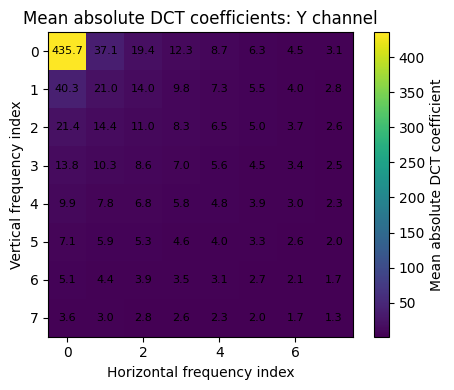

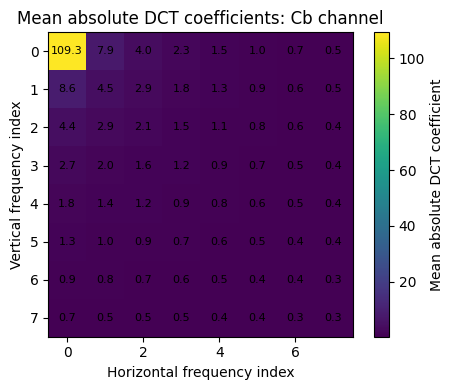

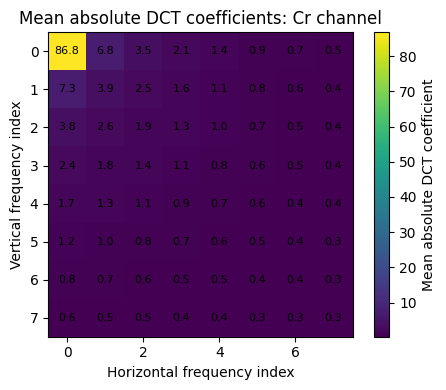

In [18]:
def plot_dct_heatmap(matrix, title):
    plt.figure(figsize=(5, 4))
    plt.imshow(matrix)
    plt.colorbar(label="Mean absolute DCT coefficient")
    plt.title(title)
    plt.xlabel("Horizontal frequency index")
    plt.ylabel("Vertical frequency index")

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            plt.text(j, i, f"{matrix[i, j]:.1f}", ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()


plot_dct_heatmap(mean_abs_dct["Y"], "Mean absolute DCT coefficients: Y channel")
plot_dct_heatmap(mean_abs_dct["Cb"], "Mean absolute DCT coefficients: Cb channel")
plot_dct_heatmap(mean_abs_dct["Cr"], "Mean absolute DCT coefficients: Cr channel")